
# 미니 프로젝트: 데이터로 이야기하기 (EDA Template)

**목표**
- 당뇨병 데이터(`train.csv`)를 사용해 스스로 **가설을 세우고**, **탐색**, **시각화**, **인사이트**를 도출합니다.  
- 각 단계의 **TODO**를 채워주세요.

---

## ✅ 실습 진행표
1. 가설 세우기  
2. 데이터 불러오기  
3. 기본 EDA (info/describe/결측)  
4. 결측치 처리 (0 → NaN → 채우기)  
5. 단변량 시각화  
6. 이변량 시각화  
7. 상관관계 Heatmap  
8. 인사이트 정리


In [116]:

# 1️⃣ 가설 세우기
# ------------------------------------------------
# 아래에 자신만의 가설을 1~2개 작성해보세요.
# ------------------------------------------------

# TODO: 여기에 가설을 적으세요
hypothesis_1 = "체내 glucose수치가 올라가면 그에 대한 항상성 유지를 위해 인슐린이 분비된다."
hypothesis_2 = "glucose 수치가 높을수록 당뇨 진단을 받을 확률이 높다."

In [117]:

# 2️⃣ 데이터 불러오기
# ------------------------------------------------
# 'train.csv' 파일을 불러오세요.
# - 같은 폴더에 두거나, 절대/상대 경로를 명시하세요.
# ------------------------------------------------

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('train.csv')

# TODO: 파일 경로를 채우세요


In [118]:

# 3️⃣ 기본 EDA
# ------------------------------------------------
# - 데이터의 구조와 기본 통계를 확인합니다.
# - 결측치(NA) 여부와 비율을 확인합니다.
# ------------------------------------------------

df.info()
df.describe()
# 결측치 개수/비율 보기
na_count = df.isna().sum().sort_values(ascending=False)
na_ratio = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
display(na_count, na_ratio)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 652 entries, 0 to 651
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        652 non-null    object 
 1   Pregnancies               652 non-null    int64  
 2   Glucose                   652 non-null    int64  
 3   BloodPressure             652 non-null    int64  
 4   SkinThickness             652 non-null    int64  
 5   Insulin                   652 non-null    int64  
 6   BMI                       652 non-null    float64
 7   DiabetesPedigreeFunction  652 non-null    float64
 8   Age                       652 non-null    int64  
 9   Outcome                   652 non-null    int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 51.1+ KB


ID                          0
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

ID                          0.0
Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Outcome                     0.0
dtype: float64

In [119]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,652.000000,652.000000,652.000000,652.000000,652.000000,652.000000,652.000000,652.000000,652.000000
mean,3.923313,120.946319,68.895706,20.440184,80.878834,31.947393,0.465133,33.510736,0.349693
std,3.327529,31.992394,19.183843,15.918604,117.748315,7.460975,0.329496,11.824817,0.477239
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.084000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,0.000000,0.000000,27.400000,0.238750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,34.000000,32.000000,0.363000,29.500000,0.000000
75%,6.000000,142.000000,80.000000,32.000000,126.000000,36.425000,0.607750,41.000000,1.000000
max,15.000000,199.000000,114.000000,99.000000,846.000000,57.300000,2.329000,81.000000,1.000000



### 🔧 결측치 처리 가이드

- 이 데이터에서는 `0`이 **실제로는 결측(미측정)** 을 의미할 수 있습니다.  
- 다음 컬럼에서 `0 → NaN`으로 바꾼 뒤, 적절한 방식으로 채우세요.

> 권장 컬럼: `["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]`  
> 채우기 아이디어: **중앙값**, 혹은 **그룹별(예: AgeBand, BMI Band)** 대표값


In [120]:

# 4️⃣ 결측치 처리 (0 → NaN → 채움) : 버전 낮아서 NaN 불가 nan으로 수정함
# ------------------------------------------------
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI','DiabetesPedigreeFunction','Age']
df[cols] = df[cols].replace(0, np.nan)
df.isnull().sum()
df

,ID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,TRAIN_000,4,103.0,60.0,33.0,192.0,24.0,0.966,33,0
1,TRAIN_001,10,133.0,68.0,NaN,NaN,27.0,0.245,36,0
2,TRAIN_002,4,112.0,78.0,40.0,NaN,39.4,0.236,38,0
3,TRAIN_003,1,119.0,88.0,41.0,170.0,45.3,0.507,26,0
4,TRAIN_004,1,114.0,66.0,36.0,200.0,38.1,0.289,21,0
...,...,...,...,...,...,...,...,...,...,...
647,TRAIN_647,1,91.0,64.0,24.0,NaN,29.2,0.192,21,0
648,TRAIN_648,10,122.0,68.0,NaN,NaN,31.2,0.258,41,0
649,TRAIN_649,8,84.0,74.0,31.0,NaN,38.3,0.457,39,0
650,TRAIN_650,2,81.0,72.0,15.0,76.0,30.1,0.547,25,0


In [121]:
Glucose_median = df.groupby('Age')['Glucose'].transform('median')
df["Glucose"] = df['Glucose'].fillna(Glucose_median)
df.isnull().sum()

ID                            0
Pregnancies                   0
Glucose                       0
BloodPressure                30
SkinThickness               195
Insulin                     318
BMI                           7
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [122]:
df['GlucoseBand'] = pd.cut(df['Glucose'],bins=[40,100,120,160,200], labels=['저혈당','정상1','주의','위험'])
df

,ID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,GlucoseBand
0,TRAIN_000,4,103.0,60.0,33.0,192.0,24.0,0.966,33,0,정상1
1,TRAIN_001,10,133.0,68.0,NaN,NaN,27.0,0.245,36,0,주의
2,TRAIN_002,4,112.0,78.0,40.0,NaN,39.4,0.236,38,0,정상1
3,TRAIN_003,1,119.0,88.0,41.0,170.0,45.3,0.507,26,0,정상1
4,TRAIN_004,1,114.0,66.0,36.0,200.0,38.1,0.289,21,0,정상1
...,...,...,...,...,...,...,...,...,...,...,...
647,TRAIN_647,1,91.0,64.0,24.0,NaN,29.2,0.192,21,0,저혈당
648,TRAIN_648,10,122.0,68.0,NaN,NaN,31.2,0.258,41,0,주의
649,TRAIN_649,8,84.0,74.0,31.0,NaN,38.3,0.457,39,0,저혈당
650,TRAIN_650,2,81.0,72.0,15.0,76.0,30.1,0.547,25,0,저혈당


In [123]:
df.groupby('GlucoseBand')['Insulin'].mean()

/var/folders/7d/4294lrxx67jdcn0_3qst6jf00000gn/T/ipykernel_8779/1501279013.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('GlucoseBand')['Insulin'].mean()


GlucoseBand
저혈당     77.406250
정상1    125.786667
주의     194.084034
위험     290.272727
Name: Insulin, dtype: float64

In [124]:
Insulin_mean = df.groupby('GlucoseBand')['Insulin'].transform('mean')

/var/folders/7d/4294lrxx67jdcn0_3qst6jf00000gn/T/ipykernel_8779/3445821991.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Insulin_mean = df.groupby('GlucoseBand')['Insulin'].transform('mean')


In [125]:
df['Insulin'] = df['Insulin'].fillna(Insulin_mean)

In [126]:
Insulin_mean

0      125.786667
1      194.084034
2      125.786667
3      125.786667
4      125.786667
          ...    
647     77.406250
648    194.084034
649     77.406250
650     77.406250
651    125.786667
Name: Insulin, Length: 652, dtype: float64

In [127]:
df.isnull().sum()

ID                            0
Pregnancies                   0
Glucose                       0
BloodPressure                30
SkinThickness               195
Insulin                       0
BMI                           7
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
GlucoseBand                   0
dtype: int64

In [128]:
df[df['Insulin'].isna()]

,ID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,GlucoseBand


In [129]:
df

,ID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,GlucoseBand
0,TRAIN_000,4,103.0,60.0,33.0,192.000000,24.0,0.966,33,0,정상1
1,TRAIN_001,10,133.0,68.0,NaN,194.084034,27.0,0.245,36,0,주의
2,TRAIN_002,4,112.0,78.0,40.0,125.786667,39.4,0.236,38,0,정상1
3,TRAIN_003,1,119.0,88.0,41.0,170.000000,45.3,0.507,26,0,정상1
4,TRAIN_004,1,114.0,66.0,36.0,200.000000,38.1,0.289,21,0,정상1
...,...,...,...,...,...,...,...,...,...,...,...
647,TRAIN_647,1,91.0,64.0,24.0,77.406250,29.2,0.192,21,0,저혈당
648,TRAIN_648,10,122.0,68.0,NaN,194.084034,31.2,0.258,41,0,주의
649,TRAIN_649,8,84.0,74.0,31.0,77.406250,38.3,0.457,39,0,저혈당
650,TRAIN_650,2,81.0,72.0,15.0,76.000000,30.1,0.547,25,0,저혈당



## 📊 단변량 시각화 (Univariate)
- **변수 하나**의 분포를 확인합니다.  
- 히스토그램/박스플롯으로 **분포/이상치**를 파악하세요.


<Axes: xlabel='Insulin', ylabel='Count'>

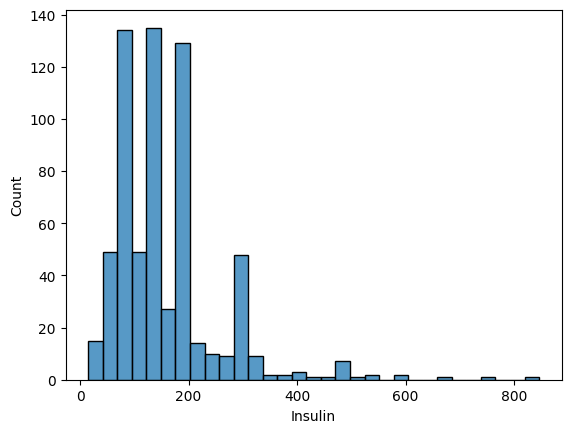

In [130]:

# 5️⃣ 단변량 시각화
# ------------------------------------------------
sns.histplot(df['Insulin'])

<Axes: ylabel='Glucose'>

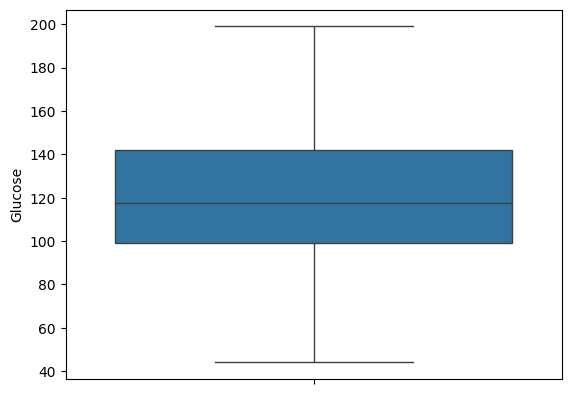

In [137]:
sns.boxplot(df['Glucose'])


## 🔗 이변량 시각화 (Bivariate)
- **두 변수 간 관계**를 시각화합니다.  
- 예시: `Glucose vs Outcome` 박스플롯, `Age vs BMI` 산점도 등


<Axes: xlabel='Outcome', ylabel='Glucose'>

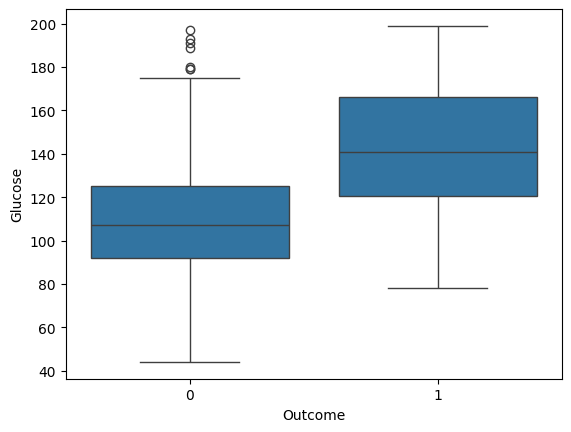

In [139]:

# 6️⃣ 이변량 시각화
# ------------------------------------------------
sns.boxplot(df, x='Outcome' , y='Glucose')

<Axes: xlabel='Glucose', ylabel='Insulin'>

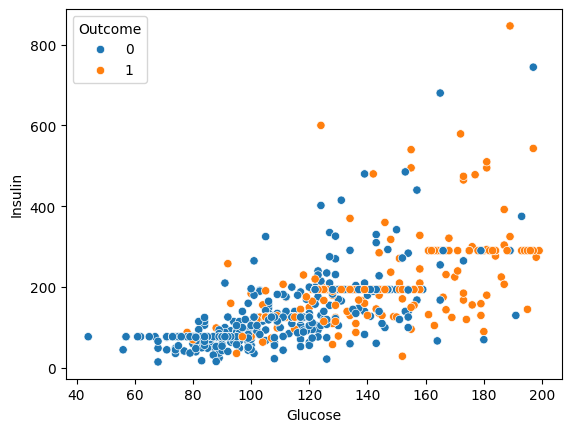

In [141]:
sns.scatterplot(df, x='Glucose' , y='Insulin', hue='Outcome')


## 🔥 상관관계 Heatmap
- 수치형 변수 간 상관관계를 계산하고 시각화합니다.  
- `Outcome`과의 관련성이 큰 변수를 찾아보세요.


In [134]:

# 7️⃣ 상관관계 Heatmap
# ------------------------------------------------


<Axes: >

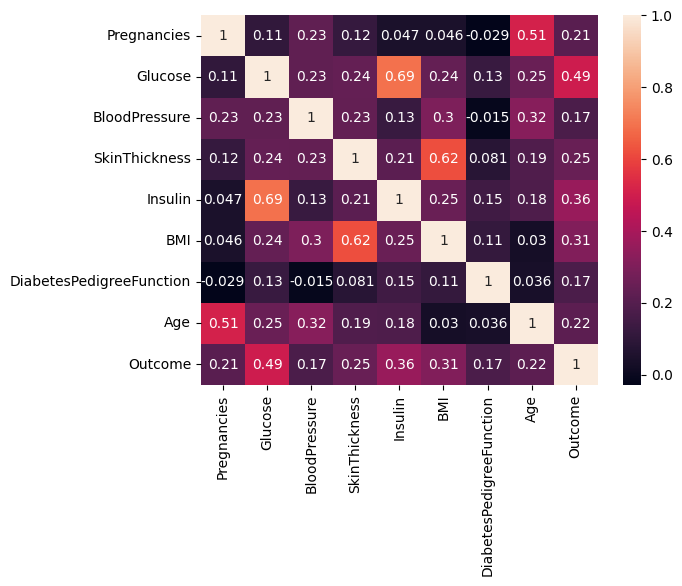

In [135]:
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True)


## 🧾 인사이트/결론 정리
- 가설이 맞았는가?  
- 어떤 변수들이 Outcome과 강한 관련이 있는가?  
- 추가로 확인해보고 싶은 점은?


In [136]:

# 8️⃣ 인사이트 정리 (자유 서술)
# ------------------------------------------------

insight = """
✅ 가설 1: 체내 glucose수치가 올라가면 그에 대한 항상성 유지를 위해 인슐린이 분비된다. 
- 근거: 산점도 그래프를 보면 glucose수치 증가시 Insulin수치도 증가하는 경향이 보임

✅ 가설 2: glucose 수치가 높을수록 당뇨 진단을 받을 확률이 높다.
- 근거: glucose가 당뇨병 유무의 가장 큰 상관관계를 가진다.


📌 다음에 해볼 일(옵션):
- 이상치 처리/스케일링/모델 학습과의 연결
- 새로운 파생변수(예: BMI Band, Age Band) 시도

1. 가설이 맞았음
2. Outcome과 강한관련이 있는 기준을 0.3이상이라고 가정하면 glucose, Insulin, BMI이다.
3. 데이터에서 혈당이 높은데 당뇨 진단을 받지 않은 사람의 이유
(1) 측정된 혈당 수치가 공복혈당이 아니라 무작위 혈당측정치라면 혈당 데이터가 신뢰할수없음
(2) 공복혈당 측정치라면 진단을 받아야되는데 받지않은 사람임
(3) 공복혈당치이며 진단 기준에 부합하지않는다면 신뢰할 데이터임


SyntaxError: incomplete input (167326332.py, line 4)